### 1.4.9.2. Runge-Kutta Methods

$$
k_1 = f(x_n, y_n),\ \ k_2 = f(x_n + \tfrac{h}{2}, y_n + \tfrac{h}{2}k_1),\ \
k_3 = f(x_n + \tfrac{h}{2}, y_n + \tfrac{h}{2}k_2),\ \ k_4 = f(x_n + h, y_n + h k_3),
$$

$$
y_{n+1} = y_n + \frac{h}{6}\big(k_1 + 2k_2 + 2k_3 + k_4\big) \quad (\text{RK4}).
$$

**Explanation:**

Runge–Kutta methods improve on [Euler](./01_eulers_method.ipynb) by replacing the single slope with a *weighted average* of slopes sampled across the step. The **improved Euler** (Heun) method is the second-order predictor–corrector $y_{n+1} = y_n + \tfrac{h}{2}(k_1 + k_2)$ with global error $O(h^2)$. The **classical fourth-order method (RK4)** samples four slopes — once at the start, twice at the midpoint, once at the end — and is globally $O(h^4)$ accurate, so it gains several digits for the same step size. RK4 is the default explicit integrator for simulating ODE models throughout dynamics, control, and the differentiable solvers behind neural ODEs.

**Properties:**
- Improved Euler: local $O(h^3)$, global $O(h^2)$; RK4: local $O(h^5)$, global $O(h^4)$.
- Halving $h$ cuts the RK4 error by about $\tfrac{1}{16}$, versus $\tfrac12$ for Euler.

**Numerical Example:**

Approximate $y(1.5)$ for $y' = 2xy$, $y(1) = 1$, $h = 0.1$ with RK4. The first step ($x_0 = 1$, $y_0 = 1$):

$$
k_1 = f(1, 1) = 2, \qquad
k_2 = f(1.05,\, 1 + 0.05\cdot 2) = 2(1.05)(1.1) = 2.31,
$$

$$
k_3 = f(1.05,\, 1 + 0.05\cdot 2.31) = 2(1.05)(1.1155) = 2.3426, \qquad
k_4 = f(1.1,\, 1 + 0.1\cdot 2.3426) = 2(1.1)(1.2343) = 2.7154 .
$$

$$
y_1 = 1 + \frac{0.1}{6}\big(2 + 2(2.31) + 2(2.3426) + 2.7154\big) = 1.2337 ,
$$

matching the exact $e^{1.1^2 - 1} = e^{0.21} = 1.2337$ to four decimals. Continuing, RK4 gives $y(1.5) \approx 3.4904$ versus the exact $3.4903$ — far better than Euler's $2.926$.

In [1]:
import numpy as np

def step_methods(slope, x0, y0, step, target):
    points = int(round((target - x0) / step))
    x = x0
    improved, rk4 = y0, y0
    for _ in range(points):
        predictor = improved + step * slope(x, improved)
        improved = improved + step / 2 * (slope(x, improved) + slope(x + step, predictor))
        k1 = slope(x, rk4)
        k2 = slope(x + step / 2, rk4 + step / 2 * k1)
        k3 = slope(x + step / 2, rk4 + step / 2 * k2)
        k4 = slope(x + step, rk4 + step * k3)
        rk4 = rk4 + step / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        x += step
    return improved, rk4

slope = lambda x, y: 2 * x * y
improved_value, rk4_value = step_methods(slope, 1.0, 1.0, 0.1, 1.5)
exact_value = np.exp(1.5**2 - 1)

print(f"improved Euler y(1.5) = {improved_value:.4f}")
print(f"RK4           y(1.5) = {rk4_value:.4f}")
print(f"exact         y(1.5) = {exact_value:.4f}")
print(f"RK4 error = {abs(rk4_value - exact_value):.2e}")

improved Euler y(1.5) = 3.4509
RK4           y(1.5) = 3.4902
exact         y(1.5) = 3.4903
RK4 error = 1.32e-04


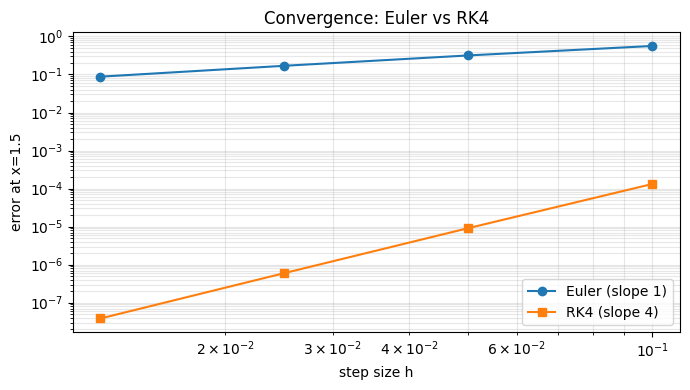

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euler_value(slope, step):
    x, y = 1.0, 1.0
    for _ in range(int(round(0.5 / step))):
        y += step * slope(x, y); x += step
    return y

steps = np.array([0.1, 0.05, 0.025, 0.0125])
exact = np.exp(1.5**2 - 1)
euler_err = [abs(euler_value(slope, h) - exact) for h in steps]
rk4_err = [abs(step_methods(slope, 1.0, 1.0, h, 1.5)[1] - exact) for h in steps]

plt.figure(figsize=(7, 4))
plt.loglog(steps, euler_err, "o-", label="Euler (slope 1)")
plt.loglog(steps, rk4_err, "s-", label="RK4 (slope 4)")
plt.xlabel("step size h"); plt.ylabel("error at x=1.5"); plt.title("Convergence: Euler vs RK4")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Euler's Method](./01_eulers_method.ipynb) | [Next: Numerical Methods for Systems and Higher-Order Equations ➡️](./03_numerical_methods_for_systems_and_higher_order.ipynb)